In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

In [32]:
df = pd.read_csv('/content/global_supply_chain_disruption_v1.csv')
df

,Order_ID,Order_Date,Origin_City,Destination_City,Route_Type,Transportation_Mode,Product_Category,Base_Lead_Time_Days,Scheduled_Lead_Time_Days,Actual_Lead_Time_Days,Delay_Days,Delivery_Status,Disruption_Event,Geopolitical_Risk_Index,Weather_Severity_Index,Inflation_Rate_Pct,Shipping_Cost_USD,Order_Weight_Kg,Mitigation_Action_Taken
0,ORD-00BCB25B,4/5/2024,"Shanghai, CN","Los Angeles, US",Pacific,Sea,Textiles,18,21,18,0,On Time,NaN,0.81,8.9,1.83,1611.81,1781,Standard Shipping
1,ORD-EBDBACB7,9/8/2024,"Tokyo, JP","Singapore, SG",Intra-Asia,Air,Pharmaceuticals,2,5,2,0,On Time,NaN,0.70,5.9,2.44,76127.70,8142,Standard Shipping
2,ORD-4052DA06,1/28/2025,"Shenzhen, CN","Rotterdam, NL",Suez,Air,Semiconductors,3,4,4,0,On Time,NaN,0.46,8.1,3.86,13699.18,1706,Standard Shipping
3,ORD-03F41ABB,2/4/2025,"Santos, BR","Shanghai, CN",Commodity,Sea,Consumer Electronics,35,36,35,0,On Time,NaN,0.88,9.3,1.58,5448.24,5796,Standard Shipping
4,ORD-347A88A6,5/20/2025,"Hamburg, DE","New York, US",Atlantic,Sea,Raw Materials,12,13,12,0,On Time,NaN,0.55,2.9,3.12,1215.98,1569,Standard Shipping
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,ORD-525E3FA5,10/14/2024,"Tokyo, JP","Singapore, SG",Intra-Asia,Sea,Consumer Electronics,7,8,8,0,On Time,NaN,0.58,8.1,3.38,7346.21,9299,Standard Shipping
9996,ORD-5E9DBD46,9/10/2024,"Tokyo, JP","Singapore, SG",Intra-Asia,Sea,Textiles,7,10,7,0,On Time,NaN,0.37,5.5,2.34,4112.06,6003,Standard Shipping
9997,ORD-E6949429,7/13/2024,"Hamburg, DE","New York, US",Atlantic,Sea,Raw Materials,12,13,12,0,On Time,NaN,0.84,1.0,4.56,7346.20,7985,Standard Shipping
9998,ORD-29B9A2DA,7/21/2024,"Mumbai, IN","Felixstowe, UK",Suez,Sea,Semiconductors,24,27,25,0,On Time,NaN,0.53,4.7,1.05,5810.94,7596,Standard Shipping


In [33]:
df.head()

,Order_ID,Order_Date,Origin_City,Destination_City,Route_Type,Transportation_Mode,Product_Category,Base_Lead_Time_Days,Scheduled_Lead_Time_Days,Actual_Lead_Time_Days,Delay_Days,Delivery_Status,Disruption_Event,Geopolitical_Risk_Index,Weather_Severity_Index,Inflation_Rate_Pct,Shipping_Cost_USD,Order_Weight_Kg,Mitigation_Action_Taken
0,ORD-00BCB25B,4/5/2024,"Shanghai, CN","Los Angeles, US",Pacific,Sea,Textiles,18,21,18,0,On Time,NaN,0.81,8.9,1.83,1611.81,1781,Standard Shipping
1,ORD-EBDBACB7,9/8/2024,"Tokyo, JP","Singapore, SG",Intra-Asia,Air,Pharmaceuticals,2,5,2,0,On Time,NaN,0.70,5.9,2.44,76127.70,8142,Standard Shipping
2,ORD-4052DA06,1/28/2025,"Shenzhen, CN","Rotterdam, NL",Suez,Air,Semiconductors,3,4,4,0,On Time,NaN,0.46,8.1,3.86,13699.18,1706,Standard Shipping
3,ORD-03F41ABB,2/4/2025,"Santos, BR","Shanghai, CN",Commodity,Sea,Consumer Electronics,35,36,35,0,On Time,NaN,0.88,9.3,1.58,5448.24,5796,Standard Shipping
4,ORD-347A88A6,5/20/2025,"Hamburg, DE","New York, US",Atlantic,Sea,Raw Materials,12,13,12,0,On Time,NaN,0.55,2.9,3.12,1215.98,1569,Standard Shipping


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order_ID                  10000 non-null  object 
 1   Order_Date                10000 non-null  object 
 2   Origin_City               10000 non-null  object 
 3   Destination_City          10000 non-null  object 
 4   Route_Type                10000 non-null  object 
 5   Transportation_Mode       10000 non-null  object 
 6   Product_Category          10000 non-null  object 
 7   Base_Lead_Time_Days       10000 non-null  int64  
 8   Scheduled_Lead_Time_Days  10000 non-null  int64  
 9   Actual_Lead_Time_Days     10000 non-null  int64  
 10  Delay_Days                10000 non-null  int64  
 11  Delivery_Status           10000 non-null  object 
 12  Disruption_Event          1267 non-null   object 
 13  Geopolitical_Risk_Index   10000 non-null  float64
 14  Weather

In [35]:
df.shape

(10000, 19)

In [36]:
df.describe()

,Base_Lead_Time_Days,Scheduled_Lead_Time_Days,Actual_Lead_Time_Days,Delay_Days,Geopolitical_Risk_Index,Weather_Severity_Index,Inflation_Rate_Pct,Shipping_Cost_USD,Order_Weight_Kg
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,17.509900,19.50320,18.704300,0.947500,0.496770,4.976460,3.516010,11437.916337,5033.732500
std,10.902843,10.93356,11.662815,3.117293,0.230611,2.879658,1.209597,21086.689659,2830.996788
min,2.000000,3.00000,1.000000,0.000000,0.100000,0.000000,-1.150000,59.940000,101.000000
25%,7.000000,9.00000,7.000000,0.000000,0.300000,2.500000,2.700000,2308.387500,2590.500000
50%,18.000000,20.00000,18.000000,0.000000,0.500000,4.900000,3.500000,4520.170000,5044.500000
75%,28.000000,29.00000,28.000000,0.000000,0.690000,7.500000,4.350000,7055.107500,7493.000000
max,35.000000,38.00000,49.000000,20.000000,0.900000,10.000000,7.920000,206814.290000,9999.000000


In [37]:
df.columns

Index(['Order_ID', 'Order_Date', 'Origin_City', 'Destination_City',
       'Route_Type', 'Transportation_Mode', 'Product_Category',
       'Base_Lead_Time_Days', 'Scheduled_Lead_Time_Days',
       'Actual_Lead_Time_Days', 'Delay_Days', 'Delivery_Status',
       'Disruption_Event', 'Geopolitical_Risk_Index', 'Weather_Severity_Index',
       'Inflation_Rate_Pct', 'Shipping_Cost_USD', 'Order_Weight_Kg',
       'Mitigation_Action_Taken'],
      dtype='object')

In [38]:
import pandas as pd
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Order_Year'] = df['Order_Date'].dt.year
df['Order_Month'] = df['Order_Date'].dt.month
df['Order_Day'] = df['Order_Date'].dt.day
df['Order_DayOfweek'] = df['Order_Date'].dt.dayofweek

df = df.drop('Order_ID', axis=1)
df.head()

,Order_Date,Origin_City,Destination_City,Route_Type,Transportation_Mode,Product_Category,Base_Lead_Time_Days,Scheduled_Lead_Time_Days,Actual_Lead_Time_Days,Delay_Days,...,Geopolitical_Risk_Index,Weather_Severity_Index,Inflation_Rate_Pct,Shipping_Cost_USD,Order_Weight_Kg,Mitigation_Action_Taken,Order_Year,Order_Month,Order_Day,Order_DayOfweek
0,2024-04-05,"Shanghai, CN","Los Angeles, US",Pacific,Sea,Textiles,18,21,18,0,...,0.81,8.9,1.83,1611.81,1781,Standard Shipping,2024,4,5,4
1,2024-09-08,"Tokyo, JP","Singapore, SG",Intra-Asia,Air,Pharmaceuticals,2,5,2,0,...,0.70,5.9,2.44,76127.70,8142,Standard Shipping,2024,9,8,6
2,2025-01-28,"Shenzhen, CN","Rotterdam, NL",Suez,Air,Semiconductors,3,4,4,0,...,0.46,8.1,3.86,13699.18,1706,Standard Shipping,2025,1,28,1
3,2025-02-04,"Santos, BR","Shanghai, CN",Commodity,Sea,Consumer Electronics,35,36,35,0,...,0.88,9.3,1.58,5448.24,5796,Standard Shipping,2025,2,4,1
4,2025-05-20,"Hamburg, DE","New York, US",Atlantic,Sea,Raw Materials,12,13,12,0,...,0.55,2.9,3.12,1215.98,1569,Standard Shipping,2025,5,20,1


In [39]:
df['Is_Delayed'] = df['Delay_Days'].apply(lambda x: 1 if x > 0 else 0)

print(df['Is_Delayed'].value_counts(normalize=True))

Is_Delayed
0    0.871
1    0.129
Name: proportion, dtype: float64


In [40]:
leaky_cols = [
    'Delay_Days',
    'Actual_Lead_Time_Days',
    'Delivery_Status',
    'Disruption_Event',
    'Mitigation_Action_Taken'
]
df = df.drop(leaky_cols, axis=1)
df.head()

,Order_Date,Origin_City,Destination_City,Route_Type,Transportation_Mode,Product_Category,Base_Lead_Time_Days,Scheduled_Lead_Time_Days,Geopolitical_Risk_Index,Weather_Severity_Index,Inflation_Rate_Pct,Shipping_Cost_USD,Order_Weight_Kg,Order_Year,Order_Month,Order_Day,Order_DayOfweek,Is_Delayed
0,2024-04-05,"Shanghai, CN","Los Angeles, US",Pacific,Sea,Textiles,18,21,0.81,8.9,1.83,1611.81,1781,2024,4,5,4,0
1,2024-09-08,"Tokyo, JP","Singapore, SG",Intra-Asia,Air,Pharmaceuticals,2,5,0.70,5.9,2.44,76127.70,8142,2024,9,8,6,0
2,2025-01-28,"Shenzhen, CN","Rotterdam, NL",Suez,Air,Semiconductors,3,4,0.46,8.1,3.86,13699.18,1706,2025,1,28,1,0
3,2025-02-04,"Santos, BR","Shanghai, CN",Commodity,Sea,Consumer Electronics,35,36,0.88,9.3,1.58,5448.24,5796,2025,2,4,1,0
4,2025-05-20,"Hamburg, DE","New York, US",Atlantic,Sea,Raw Materials,12,13,0.55,2.9,3.12,1215.98,1569,2025,5,20,1,0


In [41]:
df.columns


Index(['Order_Date', 'Origin_City', 'Destination_City', 'Route_Type',
       'Transportation_Mode', 'Product_Category', 'Base_Lead_Time_Days',
       'Scheduled_Lead_Time_Days', 'Geopolitical_Risk_Index',
       'Weather_Severity_Index', 'Inflation_Rate_Pct', 'Shipping_Cost_USD',
       'Order_Weight_Kg', 'Order_Year', 'Order_Month', 'Order_Day',
       'Order_DayOfweek', 'Is_Delayed'],
      dtype='object')

In [42]:
safe_cols = [
    'Origin_City',
    'Destination_City',
    'Route_Type',
    'Transportation_Mode',
    'Product_Category',
    'Base_Lead_Time_Days',
    'Scheduled_Lead_Time_Days',
    'Geopolitical_Risk_Index',
    'Weather_Severity_Index',
    'Inflation_Rate_Pct',
    'Shipping_Cost_USD',
    'Order_Weight_Kg',
    'Order_Year',
    'Order_Month',
    'Order_Day',
    'Order_DayOfweek',
]

x = df[safe_cols].copy()
y = df['Is_Delayed'].copy()

print("Features", x.columns.tolist())
print("Target distribution: \n", y.value_counts(normalize=True))

Features ['Origin_City', 'Destination_City', 'Route_Type', 'Transportation_Mode', 'Product_Category', 'Base_Lead_Time_Days', 'Scheduled_Lead_Time_Days', 'Geopolitical_Risk_Index', 'Weather_Severity_Index', 'Inflation_Rate_Pct', 'Shipping_Cost_USD', 'Order_Weight_Kg', 'Order_Year', 'Order_Month', 'Order_Day', 'Order_DayOfweek']
Target distribution: 
 Is_Delayed
0    0.871
1    0.129
Name: proportion, dtype: float64


In [43]:
from sklearn.preprocessing import LabelEncoder

cat_cols = x.select_dtypes(include='object').columns
le = LabelEncoder()

for col in cat_cols:
    x[col] = le.fit_transform(x[col])
x.head()

,Origin_City,Destination_City,Route_Type,Transportation_Mode,Product_Category,Base_Lead_Time_Days,Scheduled_Lead_Time_Days,Geopolitical_Risk_Index,Weather_Severity_Index,Inflation_Rate_Pct,Shipping_Cost_USD,Order_Weight_Kg,Order_Year,Order_Month,Order_Day,Order_DayOfweek
0,3,1,3,1,6,18,21,0.81,8.9,1.83,1611.81,1781,2024,4,5,4
1,5,5,2,0,3,2,5,0.70,5.9,2.44,76127.70,8142,2024,9,8,6
2,4,3,4,0,5,3,4,0.46,8.1,3.86,13699.18,1706,2025,1,28,1
3,2,4,1,1,1,35,36,0.88,9.3,1.58,5448.24,5796,2025,2,4,1
4,0,2,0,1,4,12,13,0.55,2.9,3.12,1215.98,1569,2025,5,20,1


In [44]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=23)

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Train shape: (8000, 16)
Test shape: (2000, 16)

Train target distribution:
Is_Delayed
0    0.87
1    0.13
Name: proportion, dtype: float64

Test target distribution:
Is_Delayed
0    0.875
1    0.125
Name: proportion, dtype: float64


In [57]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train_sc = sc.fit_transform(x_train)
x_test_sc = sc.transform(x_test)

In [58]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=5000, class_weight='balanced')
lr.fit(x_train_sc, y_train)

y_pred_lr = lr.predict(x_test_sc)
y_prob_lr = lr.predict_proba(x_test_sc)[:,1]

In [59]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(class_weight='balanced', n_estimators=300, random_state=23)
rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)
y_prob_rf = rf.predict_proba(x_test)[:,1]

In [60]:
from xgboost import XGBClassifier

xgb = XGBClassifier(eval_metric='logloss',
                    scale_pos_weight=7,
                    n_estimators=300,
                    learning_rate=0.05,
                    max_depth=6,
                    random_state=23)
xgb.fit(x_train, y_train)

y_pred_xgb = xgb.predict(x_test)
y_prob_xgb = xgb.predict_proba(x_test)[:,1]

In [62]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf', probability=True, class_weight='balanced')
svm.fit(x_train_sc, y_train)

y_pred_svm = svm.predict(x_test_sc)
y_prob_svm = svm.predict_proba(x_test_sc)[:,1]

In [63]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train_sc, y_train)

y_pred_knn = knn.predict(x_test_sc)
y_prob_knn = knn.predict_proba(x_test_sc)[:,1]

In [72]:
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

models = {
    "LR": (y_pred_lr, y_prob_lr),
    "RF": (y_pred_rf, y_prob_rf),
    "XGB": (y_pred_xgb, y_prob_xgb),
    "SVM": (y_pred_svm, y_prob_svm),
    "KNN": (y_pred_knn, y_prob_knn)
}

for name, (pred, prob) in models.items():
    print(f"\n==== {name} ====")
    print("Accuracy:", accuracy_score(y_test, pred))
    print("ROC-AUC:", roc_auc_score(y_test, prob))
    print(classification_report(y_test, pred))


==== LR ====
Accuracy: 0.6195
ROC-AUC: 0.6649371428571428
              precision    recall  f1-score   support

           0       0.92      0.62      0.74      1750
           1       0.19      0.60      0.28       250

    accuracy                           0.62      2000
   macro avg       0.55      0.61      0.51      2000
weighted avg       0.83      0.62      0.68      2000


==== RF ====
Accuracy: 0.9025
ROC-AUC: 0.8301622857142857
              precision    recall  f1-score   support

           0       0.90      1.00      0.95      1750
           1       0.98      0.22      0.36       250

    accuracy                           0.90      2000
   macro avg       0.94      0.61      0.66      2000
weighted avg       0.91      0.90      0.87      2000


==== XGB ====
Accuracy: 0.9435
ROC-AUC: 0.9065965714285714
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1750
           1       0.87      0.64      0.74       250

    

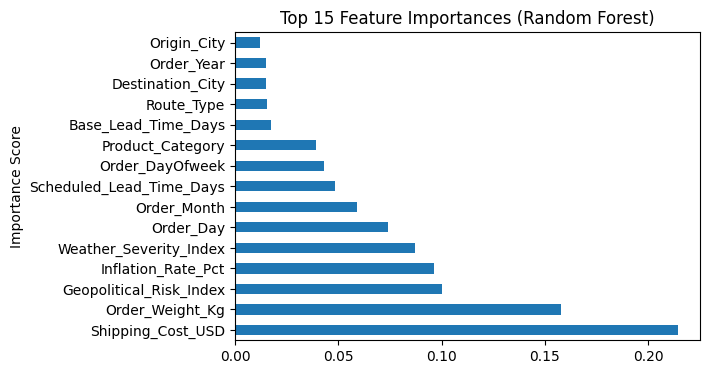

,0
Shipping_Cost_USD,0.214357
Order_Weight_Kg,0.157725
Geopolitical_Risk_Index,0.100020
Inflation_Rate_Pct,0.096298
Weather_Severity_Index,0.087069
Order_Day,0.073857
Order_Month,0.059180
Scheduled_Lead_Time_Days,0.048434
Order_DayOfweek,0.042865
Product_Category,0.039370


In [73]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature importance from RF
rf_importance = rf.feature_importances_
feat_imp = pd.Series(rf_importance, index=x_train.columns)
feat_imp = feat_imp.sort_values(ascending=False)

plt.figure(figsize=(6,4))
feat_imp.head(15).plot(kind='barh')
plt.title("Top 15 Feature Importances (Random Forest)")
plt.ylabel("Importance Score")
plt.show()

feat_imp.head(15)

In [76]:
# -------------------------------------------------------
# Save metrics for each model
# -------------------------------------------------------

# Logistic Regression
acc_lr  = accuracy_score(y_test, y_pred_lr)
auc_lr  = roc_auc_score(y_test, y_prob_lr)

# Random Forest
acc_rf  = accuracy_score(y_test, y_pred_rf)
auc_rf  = roc_auc_score(y_test, y_prob_rf)

# XGBoost
acc_xgb = accuracy_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

# SVM
acc_svm = accuracy_score(y_test, y_pred_svm)
auc_svm = roc_auc_score(y_test, y_prob_svm)

# KNN
acc_knn = accuracy_score(y_test, y_pred_knn)
auc_knn = roc_auc_score(y_test, y_prob_knn)

# -------------------------------------------------------
# Create Comparison Table
# -------------------------------------------------------

model_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost", "SVM", "KNN"],
    "Accuracy": [acc_lr, acc_rf, acc_xgb, acc_svm, acc_knn],
    "ROC_AUC": [auc_lr, auc_rf, auc_xgb, auc_svm, auc_knn]
})

# Sort by ROC_AUC
model_results = model_results.sort_values(by="ROC_AUC", ascending=False)
print(model_results)

                 Model  Accuracy   ROC_AUC
2              XGBoost    0.9435  0.906597
1        Random Forest    0.9025  0.830162
3                  SVM    0.7560  0.723239
0  Logistic Regression    0.6195  0.664937
4                  KNN    0.8695  0.552366


In [78]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Final Best Model
xgb_final = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]),
    eval_metric='logloss',
    random_state=42
)

# Train
xgb_final.fit(x_train, y_train)

# Predict
y_pred = xgb_final.predict(x_test)
y_prob = xgb_final.predict_proba(x_test)[:,1]

# Metrics
print("=== FINAL XGBOOST MODEL ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

=== FINAL XGBOOST MODEL ===
Accuracy: 0.9415
ROC-AUC: 0.9024

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97      1750
           1       0.89      0.60      0.72       250

    accuracy                           0.94      2000
   macro avg       0.92      0.80      0.84      2000
weighted avg       0.94      0.94      0.94      2000



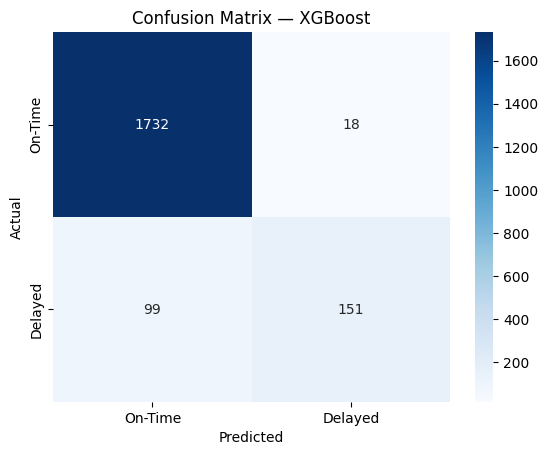

In [79]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['On-Time','Delayed'],
            yticklabels=['On-Time','Delayed'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — XGBoost")
plt.show()

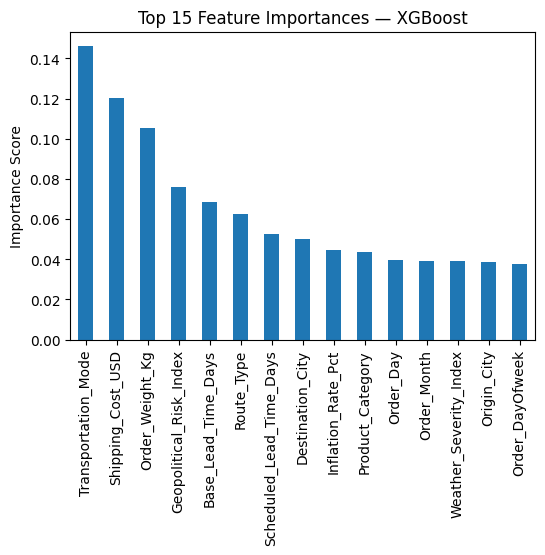

In [81]:
feat_imp = pd.Series(
    xgb_final.feature_importances_,
    index=x_train.columns
).sort_values(ascending=False).head(15)

feat_imp.plot(kind='bar', figsize=(6,4))
plt.title("Top 15 Feature Importances — XGBoost")
plt.ylabel("Importance Score")
plt.show()

In [82]:
import joblib
joblib.dump(xgb_final, "xgb_supply_chain_model.pkl")

['xgb_supply_chain_model.pkl']